# Visitor Arrivals and Hotel Guests in Macao
## A simple comparison from January to June 2026
**CISC7204 Data Science and Data Visualization**  
**ZUO ZIYI (MC642637) and WANG TINGYUE (MC642106)**

**Question:** What is the relationship between monthly visitor arrivals and hotel guests in Macao during the first half of 2026?

This notebook uses basic pandas and plotting methods from Assignment 01. Read CSV files and inspect data (Module 01); check missing values and rescale columns (Module 02); calculate correlation and draw a regression plot (Modules 03–04). We use only six monthly observations, so this is a descriptive comparison.

Keep the two CSV files beside this notebook. In Jupyter, select **Restart Kernel and Run All Cells**. The three charts are displayed below and saved as PNG files.

## 1 Data sources
Both datasets come from the Statistics and Census Service of Macao (DSEC):
- [Visitor arrivals](https://data.gov.mo/Detail?id=3546225a-2a34-4645-b01e-6752aed03993)
- [Guests of hotel establishments](https://data.gov.mo/Detail?id=00eae9c4-a51d-4fa2-bd36-7e2db18374a8)

The supplied CSV files contain the January–June 2026 monthly counts extracted from the DSEC database snapshot retrieved on 20 September 2026. No monthly values were estimated. Original JSON downloads and extraction notes are in `sources`.

Visitor arrivals and hotel guest counts measure different groups; the records do not link individual visitors to hotels. Hotel guests include guests already staying at the beginning of the period and guests registering during it. Database revisions mean these figures may differ from older news releases.

## 2 Import the libraries and read the files
`read_csv()` loads each file into a DataFrame. `head()` shows the first five rows.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
visitors = pd.read_csv("visitor_arrivals_2026H1.csv")
visitors.head()

,month,visitor_arrivals
0,2026-01,3647328
1,2026-02,4172940
2,2026-03,3393636
3,2026-04,3441396
4,2026-05,3487994


In [3]:
hotels = pd.read_csv("hotel_guests_2026H1.csv")
hotels.head()

,month,hotel_guests
0,2026-01,1250700
1,2026-02,1220459
2,2026-03,1208570
3,2026-04,1169133
4,2026-05,1183520


## 3 Put the two datasets together
First check the month labels. We then use one small extension beyond the basic exercises: `pd.merge()` matches the two tables by the month column. `how="inner"` keeps months present in both tables. Check that the result contains all six months.

In [4]:
visitors["month"] == hotels["month"]

0    True
1    True
2    True
3    True
4    True
5    True
Name: month, dtype: bool

In [5]:
df = pd.merge(visitors, hotels, on="month", how="inner")
df

,month,visitor_arrivals,hotel_guests
0,2026-01,3647328,1250700
1,2026-02,4172940,1220459
2,2026-03,3393636,1208570
3,2026-04,3441396,1169133
4,2026-05,3487994,1183520
5,2026-06,2801152,1105197


## 4 Check the data
There should be six rows, numeric count columns and no missing values. Since this dataset is complete, no values need to be filled or removed.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   month             6 non-null      object
 1   visitor_arrivals  6 non-null      int64 
 2   hotel_guests      6 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 276.0+ bytes


In [7]:
df.isnull().sum()

month               0
visitor_arrivals    0
hotel_guests        0
dtype: int64

In [8]:
df[["visitor_arrivals", "hotel_guests"]].describe()

,visitor_arrivals,hotel_guests
count,6.000000e+00,6.000000e+00
mean,3.490741e+06,1.189596e+06
std,4.421131e+05,5.024954e+04
min,2.801152e+06,1.105197e+06
25%,3.405576e+06,1.172730e+06
50%,3.464695e+06,1.196045e+06
75%,3.607494e+06,1.217487e+06
max,4.172940e+06,1.250700e+06


## 5 Compare the monthly counts
Divide the counts by one million to make the vertical axis easier to read. The two lines share the same scale.

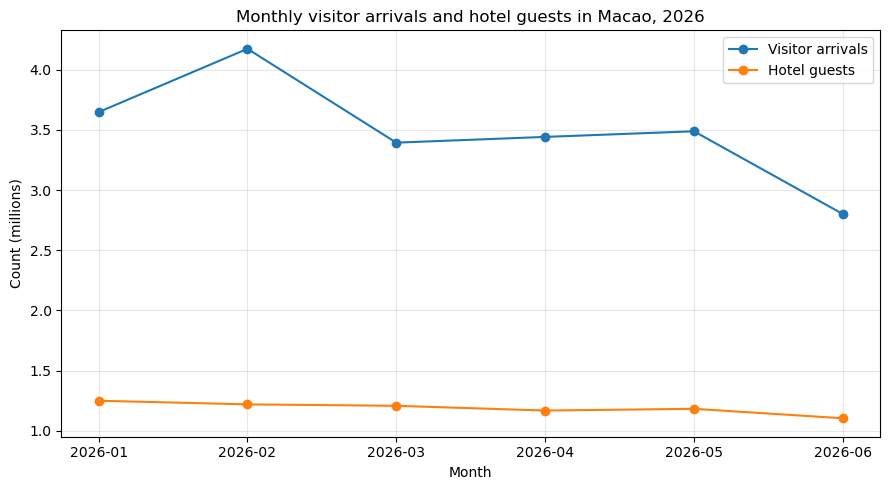

In [9]:
df["visitors_million"] = df["visitor_arrivals"] / 1000000
df["hotels_million"] = df["hotel_guests"] / 1000000

plt.figure(figsize=(9, 5))
plt.plot(df["month"], df["visitors_million"], marker="o", label="Visitor arrivals")
plt.plot(df["month"], df["hotels_million"], marker="o", label="Hotel guests")
plt.title("Monthly visitor arrivals and hotel guests in Macao, 2026")
plt.xlabel("Month")
plt.ylabel("Count (millions)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("01_monthly_counts.png", dpi=300)
plt.show()

**Observation:** Visitor arrivals peak in February. Hotel guest counts are highest in January. Both series have their lowest values in June. The visitor series changes more visibly on this scale.

## 6 Compare changes from January
The counts have different sizes. To compare their relative changes, divide each value by its January value and multiply by 100. This is a simple rescaling calculation, similar to the normalization exercises in Module 02. January is 100 for both lines; 90 means 10% below January. `loc[0, ...]` selects the January value in row 0.

In [10]:
df["visitor_index"] = df["visitor_arrivals"] / df.loc[0, "visitor_arrivals"] * 100
df["hotel_index"] = df["hotel_guests"] / df.loc[0, "hotel_guests"] * 100
df[["month", "visitor_index", "hotel_index"]].round(2)

,month,visitor_index,hotel_index
0,2026-01,100.00,100.00
1,2026-02,114.41,97.58
2,2026-03,93.04,96.63
3,2026-04,94.35,93.48
4,2026-05,95.63,94.63
5,2026-06,76.80,88.37


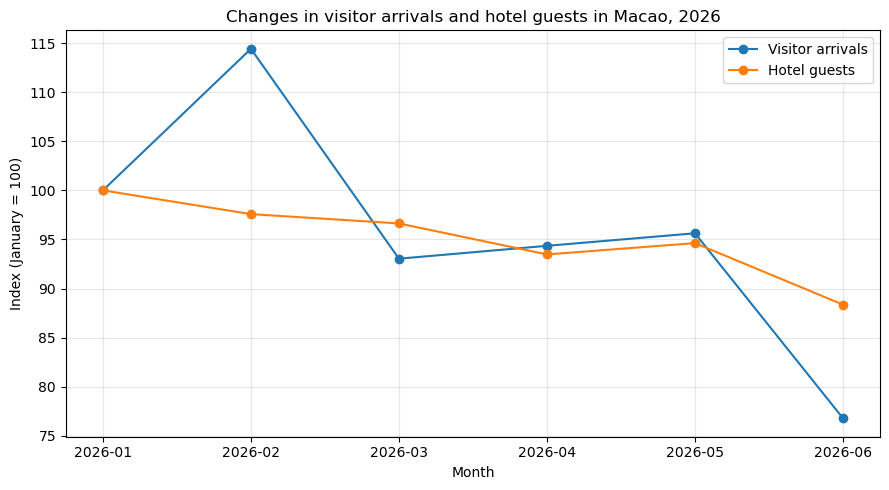

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(df["month"], df["visitor_index"], marker="o", label="Visitor arrivals")
plt.plot(df["month"], df["hotel_index"], marker="o", label="Hotel guests")
plt.title("Changes in visitor arrivals and hotel guests in Macao, 2026")
plt.xlabel("Month")
plt.ylabel("Index (January = 100)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("02_changes_from_january.png", dpi=300)
plt.show()

**Observation:** From January to February, visitor arrivals rise while hotel guests fall. From March to April, visitor arrivals rise slightly while hotel guests fall again. Both fall from February to March, rise from April to May, and fall from May to June. Therefore, the two indicators do not always move in the same direction.

## 7 Calculate correlation
As in Module 03, use `.corr()` to calculate Pearson correlation. Values near +1 indicate a positive linear relationship; values near 0 indicate little linear relationship. Read the off-diagonal value comparing the two different columns.

In [12]:
df[["visitor_arrivals", "hotel_guests"]].corr()

,visitor_arrivals,hotel_guests
visitor_arrivals,1.000000,0.792289
hotel_guests,0.792289,1.000000


A regression plot provides a second view. Each point represents one month. The line summarizes the direction of the relationship. `ci=None` hides the confidence band to keep the chart simple; we do not use the line to forecast future months.

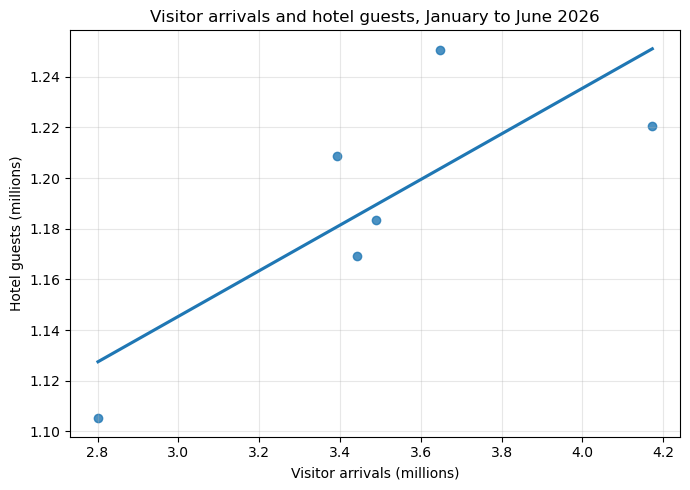

In [13]:
plt.figure(figsize=(7, 5))
sns.regplot(x="visitors_million", y="hotels_million", data=df, ci=None)
plt.title("Visitor arrivals and hotel guests, January to June 2026")
plt.xlabel("Visitor arrivals (millions)")
plt.ylabel("Hotel guests (millions)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("03_correlation.png", dpi=300)
plt.show()

## 8 Conclusion
The January-based line chart shows that the two indicators sometimes move together and sometimes move in opposite directions. Visitor arrivals rise in February and April compared with the previous month, while hotel guest counts fall. By June, both indicators are below their January levels. Using the same starting index makes these relative movements easier to compare than using two different vertical axes.

The Pearson correlation is approximately **0.79**, indicating a positive relationship across these six monthly observations. This does not mean the two indicators increase or decrease together every month. With only six observations and different definitions of the counts, we cannot conclude that visitor arrivals cause changes in hotel guests or that this pattern will continue in other periods.

## 9 Save the analysis table
`index=False` avoids adding the row numbers as an extra CSV column.

In [14]:
df.to_csv("macao_tourism_analysis_2026H1.csv", index=False)